In [3]:
!pip install transformers torch seaborn matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
    --------------------------------------- 0.3/11.2 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.2 MB 1.9 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/11.2 MB 2.8 MB/s eta 0:00:04
   ------------ --------------------------- 3.4/11.2 MB 4.7 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.2 MB 6.3 MB/s eta 0:00:01
   ------------------------- -------------- 7.1/11.2 MB 6.9 MB/s eta 0:00:01
   ---------------------------- ----------- 7.9/11.2 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 11.2/11.2 MB 7.6 MB/s  0:00:01
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------- ----- 2.4/2.7 MB 13.4 MB/s eta 0:00:01
   --------------------------

In [4]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline

C:\Users\TOP WAY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
data = {
    "Review": [
        "This product is amazing! I loved it.",
        "Worst purchase ever.",
        "Very good quality and fast delivery.",
        "I am not happy with this item.",
        "Excellent service.",
        "Average product.",
        "Highly recommended!",
        "Terrible experience.",
        "Nice packaging and good quality.",
        "Not worth the money."
    ]
}

df = pd.DataFrame(data)
df.head()

,Review
0,This product is amazing! I loved it.
1,Worst purchase ever.
2,Very good quality and fast delivery.
3,I am not happy with this item.
4,Excellent service.


In [7]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', str(text))
    text = re.sub(r'[^A-Za-z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["Clean_Review"] = df["Review"].apply(clean_text)

In [8]:
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1
)

C:\Users\TOP WAY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\TOP WAY\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(messag

In [9]:
results = classifier(df["Clean_Review"].tolist())

In [11]:
print(df.columns)

Index(['Review', 'Clean_Review'], dtype='str')


In [12]:
results = classifier(df["Clean_Review"].tolist())

df["Predicted_Sentiment"] = [r["label"] for r in results]
df["Confidence_Score"] = [round(r["score"], 3) for r in results]

df.head()

,Review,Clean_Review,Predicted_Sentiment,Confidence_Score
0,This product is amazing! I loved it.,This product is amazing I loved it,POSITIVE,1.0
1,Worst purchase ever.,Worst purchase ever,NEGATIVE,1.0
2,Very good quality and fast delivery.,Very good quality and fast delivery,POSITIVE,1.0
3,I am not happy with this item.,I am not happy with this item,NEGATIVE,1.0
4,Excellent service.,Excellent service,POSITIVE,1.0


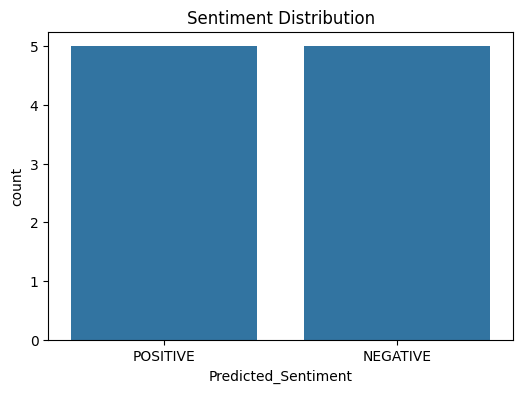

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Predicted_Sentiment")
plt.title("Sentiment Distribution")
plt.show()

In [13]:
df.to_csv("sentiment_output.csv", index=False)
print("Done")

Done
